# One-Step Fall Detection — Pure CNN Approach

This notebook implements a **single-step fall detector using only CNN methods** (no YOLO library).  
The architecture follows the grid-based detection paradigm (inspired by YOLO's core concept) but is built entirely from scratch in PyTorch.

## Core Idea
Divide each input image into an **S × S grid**. For every grid cell, the CNN simultaneously predicts:
- **B bounding boxes**: `(cx, cy, w, h, objectness_confidence)` — relative to that cell
- **C class probabilities**: `P(fall | object)`, `P(walk | object)`, `P(sit | object)`

Each output tensor has shape `[batch, S, S, B*(5) + C]`.

```
Input Image  ──►  CNN Backbone  ──►  Detection Head  ──►  [S, S, B*5 + C]
 (3,H,W)           (feature map)      (conv layers)        (grid predictions)
```

### Dataset
- Classes: **0** = fall_detected | **1** = walk | **2** = sit
- Labels: YOLO format `class_id cx cy w h` (normalized 0–1)
- Train: 374 images + 111 val (merged into train as instructed)

## 0. Imports & Configuration

In [1]:
import os
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision import models

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR  = Path('./dataset/fall_dataset')
IMG_DIR   = BASE_DIR / 'images'
LABEL_DIR = BASE_DIR / 'labels'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# ── Detection grid hyperparameters ───────────────────────────────────────────
S          = 7        # grid size S×S
B          = 2        # bounding boxes per cell
NUM_CLASSES = 3       # fall / walk / sit
IMG_SIZE   = 448      # input resolution (divisible by S*64)

CLASS_NAMES = ['fall_detected', 'walk', 'sit']
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}

print(f'Grid: {S}×{S}  |  Boxes/cell: {B}  |  Classes: {NUM_CLASSES}')
print(f'Output tensor per image: [{S}, {S}, {B*5 + NUM_CLASSES}] = [{S}, {S}, {B*5+NUM_CLASSES}]')

Device: cpu
Grid: 7×7  |  Boxes/cell: 2  |  Classes: 3
Output tensor per image: [7, 7, 13] = [7, 7, 13]


## 1. Merge val → train

In [2]:
for folder in ['images', 'labels']:
    src = BASE_DIR / folder / 'val'
    dst = BASE_DIR / folder / 'train'
    dst.mkdir(parents=True, exist_ok=True)
    for f in src.iterdir():
        dest_file = dst / f.name
        if not dest_file.exists():          # avoid overwriting duplicates
            shutil.copy(f, dest_file)

print('Val merged into train.')

n_train = len(list((IMG_DIR / 'train').glob('*.jpg')))
n_val   = len(list((IMG_DIR / 'val').glob('*.jpg')))
print(f'Train images: {n_train}  |  Val images (held-out): {n_val}')

Val merged into train.
Train images: 374  |  Val images (held-out): 89


## 2. Dataset & Label Encoding

Each label file has lines `class cx cy w h` (YOLO format, normalized).  
We convert these into an `[S, S, B*5 + C]` target tensor:

| Positions | Meaning |
|---|---|
| `[..., 0:5]` | Box 1: `cx_cell, cy_cell, w, h, obj` |
| `[..., 5:10]` | Box 2: `cx_cell, cy_cell, w, h, obj` |
| `[..., 10:13]` | Class one-hot: `[fall, walk, sit]` |

In [3]:
class FallDetectionDataset(Dataset):
    """
    Loads images and converts YOLO-format labels into
    an [S, S, B*5 + C] detection target tensor.
    """

    def __init__(self, split: str, img_size: int = 448,
                 S: int = 7, B: int = 2, C: int = 3,
                 augment: bool = False):
        self.img_dir   = IMG_DIR / split
        self.label_dir = LABEL_DIR / split
        self.img_size  = img_size
        self.S, self.B, self.C = S, B, C
        self.augment   = augment

        self.img_files = sorted(
            list(self.img_dir.glob('*.jpg')) +
            list(self.img_dir.glob('*.png'))
        )

        # ImageNet normalisation (we will use a pretrained backbone)
        self.normalize = T.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        )

        self.base_transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
        ])
        self.aug_transform = T.Compose([
            T.Resize((img_size + 64, img_size + 64)),
            T.RandomCrop(img_size),
            T.RandomHorizontalFlip(),
            T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
            T.ToTensor(),
        ])

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_path = self.img_files[idx]
        img      = Image.open(img_path).convert('RGB')

        if self.augment:
            img_tensor = self.aug_transform(img)
        else:
            img_tensor = self.base_transform(img)

        img_tensor = self.normalize(img_tensor)

        # ── Build target tensor [S, S, B*5 + C] ─────────────────────────────
        target = torch.zeros(self.S, self.S, self.B * 5 + self.C)

        txt_path = self.label_dir / (img_path.stem + '.txt')
        if txt_path.exists():
            with open(txt_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cls_id          = int(parts[0])
                    cx, cy, bw, bh  = map(float, parts[1:5])

                    # Determine which grid cell this object belongs to
                    col = int(cx * self.S)      # column index
                    row = int(cy * self.S)      # row index
                    col = min(col, self.S - 1)
                    row = min(row, self.S - 1)

                    # cx, cy relative to the cell (0–1 within that cell)
                    cx_cell = cx * self.S - col
                    cy_cell = cy * self.S - row

                    # Only assign if cell not already taken (one dominant object per cell)
                    if target[row, col, 4] == 0:    # objectness of box-1
                        # Box 1 prediction slots
                        target[row, col, 0] = cx_cell
                        target[row, col, 1] = cy_cell
                        target[row, col, 2] = bw
                        target[row, col, 3] = bh
                        target[row, col, 4] = 1.0   # objectness
                        # Box 2 same (both boxes learn from same GT during training)
                        target[row, col, 5] = cx_cell
                        target[row, col, 6] = cy_cell
                        target[row, col, 7] = bw
                        target[row, col, 8] = bh
                        target[row, col, 9] = 1.0
                        # Class one-hot
                        target[row, col, self.B * 5 + cls_id] = 1.0

        return img_tensor, target


# Quick sanity check
ds = FallDetectionDataset('train', img_size=IMG_SIZE, S=S, B=B, C=NUM_CLASSES)
img_t, tgt_t = ds[0]
print(f'Image tensor : {img_t.shape}')     # [3, 448, 448]
print(f'Target tensor: {tgt_t.shape}')     # [7, 7, 13]
print(f'Total train samples: {len(ds)}')

Image tensor : torch.Size([3, 448, 448])
Target tensor: torch.Size([7, 7, 13])
Total train samples: 396


In [4]:
# ── DataLoaders ──────────────────────────────────────────────────────────────
train_dataset = FallDetectionDataset('train', img_size=IMG_SIZE, S=S, B=B,
                                      C=NUM_CLASSES, augment=True)
val_dataset   = FallDetectionDataset('val',   img_size=IMG_SIZE, S=S, B=B,
                                      C=NUM_CLASSES, augment=False)

# num_workers has to be set to 0 to be compatible with windows
train_loader = DataLoader(train_dataset, batch_size=8,  shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=8,  shuffle=False,
                          num_workers=0, pin_memory=True)

print(f'Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}')

Train batches: 50  |  Val batches: 14


## 3. CNN Architecture

We offer **two backbone options**:

### Option A — Custom CNN from Scratch
A deep convolutional network built entirely manually, demonstrating the core methodology. Useful for understanding how convolutions, pooling, and fully-connected layers work together for detection.

### Option B — ImageNet Transfer Learning Backbone
Replace the feature extractor with a pretrained ResNet-50, then attach a custom detection head. This gives much stronger features with fewer training samples.

Both options share the **same detection head design** and **same loss function**.

In [5]:
# ════════════════════════════════════════════════════════════════════════════
#  OPTION A: Custom CNN Backbone (from scratch)
# ════════════════════════════════════════════════════════════════════════════

class ConvBlock(nn.Module):
    """Conv → BatchNorm → LeakyReLU"""
    def __init__(self, in_ch, out_ch, kernel=3, stride=1, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel, stride, padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.1, inplace=True)
        )
    def forward(self, x):
        return self.block(x)


class CustomCNNBackbone(nn.Module):
    """
    7-stage convolutional backbone.
    Input : [B, 3, 448, 448]
    Output: [B, 1024, 14, 14]

    Architecture progression:
      Stage 1: 3  → 64   |  224×224
      Stage 2: 64 → 192  |  112×112
      Stage 3: 192→ 512  |  56×56
      Stage 4: 512→ 1024 |  28×28
      Stage 5: 1024→1024 |  14×14
    """
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Stage 1
            ConvBlock(3,   64,  7, stride=2, padding=3),   # → 224
            nn.MaxPool2d(2, 2),                             # → 112

            # Stage 2
            ConvBlock(64,  192, 3),
            nn.MaxPool2d(2, 2),                             # → 56

            # Stage 3
            ConvBlock(192, 128, 1, padding=0),
            ConvBlock(128, 256, 3),
            ConvBlock(256, 256, 1, padding=0),
            ConvBlock(256, 512, 3),
            nn.MaxPool2d(2, 2),                             # → 28

            # Stage 4 — 4× repeated bottleneck
            *[nn.Sequential(
                ConvBlock(512, 256, 1, padding=0),
                ConvBlock(256, 512, 3)
              ) for _ in range(4)],
            ConvBlock(512, 512,  1, padding=0),
            ConvBlock(512, 1024, 3),
            nn.MaxPool2d(2, 2),                             # → 14

            # Stage 5
            ConvBlock(1024, 512,  1, padding=0),
            ConvBlock(512,  1024, 3),
            ConvBlock(1024, 512,  1, padding=0),
            ConvBlock(512,  1024, 3),
        )

    def forward(self, x):
        return self.features(x)


# Test
backbone_a = CustomCNNBackbone()
dummy = torch.randn(1, 3, 448, 448)
out = backbone_a(dummy)
print(f'Custom CNN backbone output: {out.shape}')   # [1, 1024, 14, 14]
n_params = sum(p.numel() for p in backbone_a.parameters()) / 1e6
print(f'Custom backbone parameters: {n_params:.1f}M')
del backbone_a, dummy, out

Custom CNN backbone output: torch.Size([1, 1024, 14, 14])
Custom backbone parameters: 22.4M


In [6]:
# ════════════════════════════════════════════════════════════════════════════
#  OPTION B: ResNet-50 ImageNet Pretrained Backbone
# ════════════════════════════════════════════════════════════════════════════

class ResNetBackbone(nn.Module):
    """
    ResNet-50 up to layer4, output [B, 2048, 14, 14] for 448×448 input.
    The final avgpool and fc are removed — we attach our own detection head.
    """
    def __init__(self, freeze_early_layers: bool = True):
        super().__init__()
        resnet   = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        # Keep everything except avgpool and fc
        self.layer0 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1 = resnet.layer1   # → 56×56
        self.layer2 = resnet.layer2   # → 28×28
        self.layer3 = resnet.layer3   # → 14×14
        self.layer4 = resnet.layer4   # → 7×7  (but we will use layer3 output for S=7 head)

        if freeze_early_layers:
            # Freeze layer0 and layer1 (very generic low-level features)
            for layer in [self.layer0, self.layer1]:
                for param in layer.parameters():
                    param.requires_grad = False

    def forward(self, x):
        x = self.layer0(x)   # [B, 64,  112, 112]
        x = self.layer1(x)   # [B, 256,  56,  56]
        x = self.layer2(x)   # [B, 512,  28,  28]
        x = self.layer3(x)   # [B, 1024, 14,  14]
        x = self.layer4(x)   # [B, 2048,  7,   7]
        return x


# Test
backbone_b = ResNetBackbone()
dummy = torch.randn(1, 3, 448, 448)
out = backbone_b(dummy)
print(f'ResNet backbone output: {out.shape}')      # [1, 2048, 7, 7]
n_params = sum(p.numel() for p in backbone_b.parameters()) / 1e6
print(f'ResNet backbone parameters: {n_params:.1f}M')
del backbone_b, dummy, out

ResNet backbone output: torch.Size([1, 2048, 14, 14])
ResNet backbone parameters: 23.5M


In [7]:
# ════════════════════════════════════════════════════════════════════════════
#  Detection Head  (shared by both backbones)
# ════════════════════════════════════════════════════════════════════════════

class DetectionHead(nn.Module):
    """
    Convolutional detection head that maps backbone features to
    an [S, S, B*5 + C] prediction grid.

    Uses 1×1 and 3×3 convolutions instead of fully-connected layers
    to retain spatial structure and reduce parameters.
    """
    def __init__(self, in_channels: int, S: int = 7, B: int = 2, C: int = 3):
        super().__init__()
        out_channels = B * 5 + C   # 13

        self.head = nn.Sequential(
            # Extra conv layers to refine features
            nn.Conv2d(in_channels, 1024, 3, padding=1, bias=False),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout2d(0.3),

            nn.Conv2d(1024, 512, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1, inplace=True),

            nn.Conv2d(512, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1, inplace=True),

            # Final 1×1 conv → prediction channels
            nn.Conv2d(256, out_channels, 1),
        )
        self.S, self.B, self.C = S, B, C

    def forward(self, x):
        # x: [B, in_channels, S, S]
        x = self.head(x)                     # [B, out_ch, S, S]
        x = x.permute(0, 2, 3, 1)           # [B, S, S, out_ch]
        return x


# ════════════════════════════════════════════════════════════════════════════
#  Full One-Step Detector
# ════════════════════════════════════════════════════════════════════════════

class OneStepCNNDetector(nn.Module):
    """
    End-to-end one-step CNN detector.
    backbone: 'custom' | 'resnet50'
    """
    def __init__(self, backbone: str = 'resnet50',
                 S: int = 7, B: int = 2, C: int = 3,
                 freeze_early: bool = True):
        super().__init__()
        self.S, self.B, self.C = S, B, C

        if backbone == 'custom':
            self.backbone = CustomCNNBackbone()    # output: [B, 1024, 14, 14]
            # Adaptive pool to exactly S×S
            self.pool     = nn.AdaptiveAvgPool2d((S, S))
            feat_channels = 1024

        elif backbone == 'resnet50':
            self.backbone = ResNetBackbone(freeze_early_layers=freeze_early)
            # ResNet layer4 output for 448 input: [B, 2048, 7, 7] = S×S already
            self.pool     = nn.AdaptiveAvgPool2d((S, S))
            feat_channels = 2048

        else:
            raise ValueError(f'Unknown backbone: {backbone}')

        self.detection_head = DetectionHead(feat_channels, S, B, C)

    def forward(self, x):
        features = self.backbone(x)          # [B, C_feat, H', W']
        features = self.pool(features)       # [B, C_feat, S, S]
        output   = self.detection_head(features)  # [B, S, S, B*5+C]
        return output


# Sanity check both backbones
for bname in ['custom', 'resnet50']:
    model = OneStepCNNDetector(backbone=bname, S=S, B=B, C=NUM_CLASSES)
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
    with torch.no_grad():
        out = model(dummy)
    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f'[{bname:8s}]  output: {out.shape}  |  params: {n_params:.1f}M')
    del model, dummy, out

[custom  ]  output: torch.Size([2, 7, 7, 13])  |  params: 33.6M
[resnet50]  output: torch.Size([2, 7, 7, 13])  |  params: 44.1M


## 4. Detection Loss Function

The loss combines four terms (following the original YOLO detection loss):

$$\mathcal{L} = \lambda_{coord} \cdot \mathcal{L}_{box} + \mathcal{L}_{obj} + \lambda_{noobj} \cdot \mathcal{L}_{noobj} + \mathcal{L}_{class}$$

| Term | What it penalises |
|---|---|
| **Box loss** | Error in `cx, cy, √w, √h` for cells WITH objects |
| **Objectness** | Confidence error in cells WITH objects |
| **No-object** | Confidence error in empty cells (down-weighted) |
| **Class loss** | Cross-entropy on class predictions for cells with objects |

In [8]:
class DetectionLoss(nn.Module):
    """
    YOLO-style multi-part detection loss.

    pred / target shape: [batch, S, S, B*5 + C]
    Layout: [cx1,cy1,w1,h1,obj1, cx2,cy2,w2,h2,obj2, cls0,cls1,cls2]
    """

    def __init__(self, S=7, B=2, C=3,
                 lambda_coord=5.0, lambda_noobj=0.5):
        super().__init__()
        self.S            = S
        self.B            = B
        self.C            = C
        self.lambda_coord = lambda_coord
        self.lambda_noobj = lambda_noobj

    def iou(self, boxes1, boxes2):
        """
        Compute IoU for boxes in [cx, cy, w, h] format (cell-relative).
        boxes1/2: [..., 4]
        """
        # Convert to x1y1x2y2
        b1_x1 = boxes1[..., 0] - boxes1[..., 2] / 2
        b1_y1 = boxes1[..., 1] - boxes1[..., 3] / 2
        b1_x2 = boxes1[..., 0] + boxes1[..., 2] / 2
        b1_y2 = boxes1[..., 1] + boxes1[..., 3] / 2

        b2_x1 = boxes2[..., 0] - boxes2[..., 2] / 2
        b2_y1 = boxes2[..., 1] - boxes2[..., 3] / 2
        b2_x2 = boxes2[..., 0] + boxes2[..., 2] / 2
        b2_y2 = boxes2[..., 1] + boxes2[..., 3] / 2

        inter_x1 = torch.max(b1_x1, b2_x1)
        inter_y1 = torch.max(b1_y1, b2_y1)
        inter_x2 = torch.min(b1_x2, b2_x2)
        inter_y2 = torch.min(b1_y2, b2_y2)

        inter = (inter_x2 - inter_x1).clamp(0) * (inter_y2 - inter_y1).clamp(0)
        area1 = boxes1[..., 2] * boxes1[..., 3]
        area2 = boxes2[..., 2] * boxes2[..., 3]
        union = area1 + area2 - inter + 1e-6
        return inter / union

    def forward(self, predictions, targets):
        """
        predictions: [batch, S, S, B*5 + C]  (raw network output)
        targets    : [batch, S, S, B*5 + C]  (ground-truth tensor)
        """
        batch = predictions.shape[0]
        pred  = predictions
        tgt   = targets

        # ── Object mask: 1 where GT has an object, 0 elsewhere ──────────────
        obj_mask   = tgt[..., 4]          # [batch, S, S]
        noobj_mask = 1 - obj_mask

        # ── Identify responsible box (highest IoU with GT) ──────────────────
        iou_scores = []
        for b in range(self.B):
            pred_box = pred[..., b*5 : b*5+4]   # [batch, S, S, 4]
            gt_box   = tgt[..., 0:4]
            iou_scores.append(self.iou(pred_box, gt_box))
        iou_stack = torch.stack(iou_scores, dim=-1)   # [batch, S, S, B]
        best_box  = iou_stack.argmax(-1)              # [batch, S, S]

        # ── Box coordinate loss (responsible box only, with objects) ─────────
        coord_loss = 0
        for b in range(self.B):
            responsible = (best_box == b).float() * obj_mask   # [batch, S, S]
            pred_xy  = pred[..., b*5   : b*5+2]
            pred_wh  = pred[..., b*5+2 : b*5+4]
            gt_xy    = tgt[..., 0:2]
            gt_wh    = tgt[..., 2:4]

            coord_loss += (responsible.unsqueeze(-1) *
                           (pred_xy - gt_xy).pow(2)).sum()
            # sqrt of w,h to equalise small/large box gradients.
            # clamp BEFORE sqrt — negative raw predictions cause sqrt(neg) = nan.
            # clamp to 1e-6 (not 0) so gradient of sqrt stays finite.
            pred_wh_safe = pred_wh.clamp(min=1e-6)
            gt_wh_safe   = gt_wh.clamp(min=1e-6)
            coord_loss += (responsible.unsqueeze(-1) *
                           (pred_wh_safe.sqrt() - gt_wh_safe.sqrt()).pow(2)).sum()

        # ── Objectness loss ───────────────────────────────────────────────────
        obj_loss   = 0
        noobj_loss = 0
        for b in range(self.B):
            pred_conf = pred[..., b*5+4]
            obj_loss   += (obj_mask   * (pred_conf - 1).pow(2)).sum()
            noobj_loss += (noobj_mask * (pred_conf - 0).pow(2)).sum()

        # ── Class loss (cross-entropy on cells with objects) ──────────────────
        pred_cls = pred[..., self.B*5:]    # [batch, S, S, C]
        gt_cls   = tgt[..., self.B*5:]
        class_loss = (obj_mask.unsqueeze(-1) *
                      F.binary_cross_entropy_with_logits(
                          pred_cls, gt_cls, reduction='none')).sum()

        total_loss = (
            self.lambda_coord * coord_loss
            + obj_loss
            + self.lambda_noobj * noobj_loss
            + class_loss
        ) / batch

        return total_loss, {
            'coord': (self.lambda_coord * coord_loss / batch).item(),
            'obj'  : (obj_loss / batch).item(),
            'noobj': (self.lambda_noobj * noobj_loss / batch).item(),
            'class': (class_loss / batch).item()
        }


# Quick test
loss_fn = DetectionLoss(S=S, B=B, C=NUM_CLASSES)
dummy_pred = torch.randn(2, S, S, B*5 + NUM_CLASSES)
dummy_tgt  = torch.zeros(2, S, S, B*5 + NUM_CLASSES)
# Simulate one valid GT object in cell (3,3) of batch item 0:
#   cx_cell=0.5, cy_cell=0.5, w=0.3, h=0.6, objectness=1, class=fall(0)
dummy_tgt[0, 3, 3, 0] = 0.5   # cx (cell-relative)
dummy_tgt[0, 3, 3, 1] = 0.5   # cy (cell-relative)
dummy_tgt[0, 3, 3, 2] = 0.3   # w  (image-normalized, must be > 0)
dummy_tgt[0, 3, 3, 3] = 0.6   # h  (image-normalized, must be > 0)
dummy_tgt[0, 3, 3, 4] = 1.0   # objectness box-1
dummy_tgt[0, 3, 3, 5] = 0.5   # cx box-2 (same GT)
dummy_tgt[0, 3, 3, 6] = 0.5
dummy_tgt[0, 3, 3, 7] = 0.3
dummy_tgt[0, 3, 3, 8] = 0.6
dummy_tgt[0, 3, 3, 9] = 1.0   # objectness box-2
dummy_tgt[0, 3, 3, 10] = 1.0  # class one-hot: fall_detected
loss, parts = loss_fn(dummy_pred, dummy_tgt)
print(f'Loss test: total={loss:.3f}  parts={parts}')
assert not torch.isnan(loss), 'Loss is NaN — check sqrt clamp!'
print('Loss sanity check PASSED — no NaN detected.')

Loss test: total=66.988  parts={'coord': 6.894847869873047, 'obj': 4.601801872253418, 'noobj': 54.373634338378906, 'class': 1.117992639541626}
Loss sanity check PASSED — no NaN detected.


## 5. Training Loop

In [9]:
def train_one_step_detector(
    model,
    train_loader,
    val_loader,
    epochs        = 60,
    lr            = 1e-3,
    unfreeze_epoch = 20,
    backbone_name = 'model'
):
    """
    Two-phase training:
      Phase 1 (0..unfreeze_epoch)   : detection head + unfrozen backbone layers only
      Phase 2 (unfreeze_epoch..end) : full model, lower LR
    """
    model    = model.to(DEVICE)
    loss_fn  = DetectionLoss(S=S, B=B, C=NUM_CLASSES)
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, epochs=epochs,
        steps_per_epoch=len(train_loader)
    )

    history = defaultdict(list)
    best_val_loss = float('inf')
    best_weights  = None

    for epoch in range(1, epochs + 1):

        # ─ Phase 2: unfreeze full model ─────────────────────────────────────
        if epoch == unfreeze_epoch:
            print(f'[Epoch {epoch}] Unfreezing full model...')
            for param in model.parameters():
                param.requires_grad = True
            optimizer = optim.AdamW(model.parameters(), lr=lr * 0.1, weight_decay=1e-4)
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=(epochs - unfreeze_epoch)
            )

        # ── Train ────────────────────────────────────────────────────────────
        model.train()
        train_losses = defaultdict(float)
        for imgs, targets in train_loader:
            imgs, targets = imgs.to(DEVICE), targets.to(DEVICE)
            optimizer.zero_grad()
            preds = model(imgs)
            loss, parts = loss_fn(preds, targets)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
            optimizer.step()
            if epoch < unfreeze_epoch:
                scheduler.step()
            for k, v in parts.items():
                train_losses[k] += v
            train_losses['total'] += loss.item()

        if epoch >= unfreeze_epoch:
            scheduler.step()

        n_batches = len(train_loader)
        for k in train_losses:
            train_losses[k] /= n_batches

        # ── Validate ─────────────────────────────────────────────────────────
        model.eval()
        val_losses = defaultdict(float)
        with torch.no_grad():
            for imgs, targets in val_loader:
                imgs, targets = imgs.to(DEVICE), targets.to(DEVICE)
                preds = model(imgs)
                loss, parts = loss_fn(preds, targets)
                val_losses['total'] += loss.item()
                for k, v in parts.items():
                    val_losses[k] += v

        n_val = len(val_loader)
        for k in val_losses:
            val_losses[k] /= n_val

        # ── Log ──────────────────────────────────────────────────────────────
        for k in train_losses:
            history[f'train_{k}'].append(train_losses[k])
        for k in val_losses:
            history[f'val_{k}'].append(val_losses[k])

        if val_losses['total'] < best_val_loss:
            best_val_loss = val_losses['total']
            best_weights  = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 10 == 0 or epoch == 1:
            print(f'Epoch {epoch:3d}/{epochs} | '
                  f'Train: {train_losses["total"]:.3f} '
                  f'(coord={train_losses["coord"]:.2f} '
                  f'obj={train_losses["obj"]:.2f} '
                  f'cls={train_losses["class"]:.2f}) | '
                  f'Val: {val_losses["total"]:.3f}')

    print(f'\nBest val loss: {best_val_loss:.4f}')
    model.load_state_dict(best_weights)
    torch.save(model.state_dict(), f'{backbone_name}_one_step_best.pth')
    return model, dict(history)

In [10]:
# ── Train both variants ───────────────────────────────────────────────────────
EPOCHS        = 60
UNFREEZE_AT   = 20

trained_detectors = {}
all_histories     = {}

for bname in ['custom', 'resnet50']:
    print(f'\n{"="*60}')
    print(f'  Training One-Step Detector — backbone: {bname}')
    print('='*60)
    model = OneStepCNNDetector(
        backbone=bname, S=S, B=B, C=NUM_CLASSES,
        freeze_early=(bname == 'resnet50')
    )
    model, history = train_one_step_detector(
        model, train_loader, val_loader,
        epochs=EPOCHS, lr=1e-3,
        unfreeze_epoch=UNFREEZE_AT,
        backbone_name=bname
    )
    trained_detectors[bname] = model
    all_histories[bname]     = history

print('\nAll detectors trained.')


  Training One-Step Detector — backbone: custom


C:\Users\fredb\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   1/60 | Train: 11.722 (coord=4.16 obj=2.03 cls=2.41) | Val: 6.077
Epoch  10/60 | Train: 5.403 (coord=1.51 obj=1.65 cls=1.86) | Val: 7.791
[Epoch 20] Unfreezing full model...
Epoch  20/60 | Train: 4.580 (coord=0.87 obj=1.57 cls=1.81) | Val: 4.123
Epoch  30/60 | Train: 4.122 (coord=0.74 obj=1.49 cls=1.54) | Val: 3.937
Epoch  40/60 | Train: 3.799 (coord=0.66 obj=1.44 cls=1.33) | Val: 3.828
Epoch  50/60 | Train: 3.684 (coord=0.60 obj=1.44 cls=1.29) | Val: 3.810
Epoch  60/60 | Train: 3.503 (coord=0.58 obj=1.41 cls=1.16) | Val: 3.791

Best val loss: 3.7489

  Training One-Step Detector — backbone: resnet50
Epoch   1/60 | Train: 15.508 (coord=6.29 obj=1.93 cls=2.47) | Val: 8.251
Epoch  10/60 | Train: 3.482 (coord=1.02 obj=1.20 cls=0.79) | Val: 3.580
[Epoch 20] Unfreezing full model...
Epoch  20/60 | Train: 2.329 (coord=0.65 obj=0.95 cls=0.34) | Val: 3.434
Epoch  30/60 | Train: 1.141 (coord=0.30 obj=0.49 cls=0.05) | Val: 3.855
Epoch  40/60 | Train: 0.718 (coord=0.19 obj=0.29 cls=0.03) |

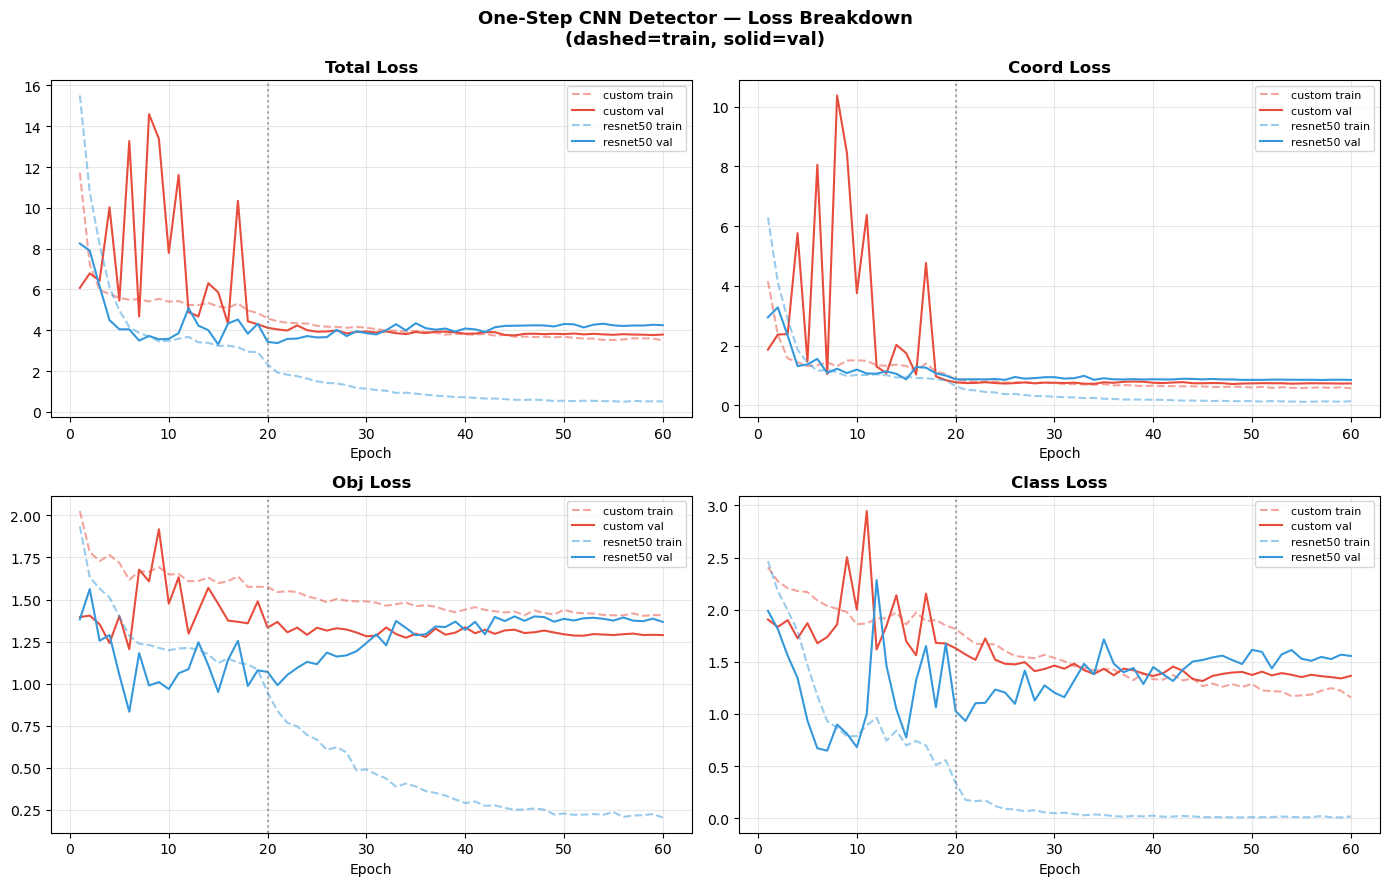

In [11]:
# ── Training curves ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
metrics   = ['total', 'coord', 'obj', 'class']
colors    = {'custom': '#e74c3c', 'resnet50': '#3498db'}

for ax, metric in zip(axes.flatten(), metrics):
    for bname, hist in all_histories.items():
        ep = range(1, len(hist[f'train_{metric}']) + 1)
        ax.plot(ep, hist[f'train_{metric}'], '--',
                color=colors[bname], alpha=0.5, label=f'{bname} train')
        ax.plot(ep, hist[f'val_{metric}'],   '-',
                color=colors[bname], label=f'{bname} val')
    ax.set_title(f'{metric.capitalize()} Loss', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.axvline(UNFREEZE_AT, color='gray', linestyle=':', alpha=0.7,
               label='unfreeze')

plt.suptitle('One-Step CNN Detector — Loss Breakdown\n(dashed=train, solid=val)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('one_step_cnn_training.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Inference & Post-Processing

Converting the raw `[S, S, B*5+C]` output tensor back into image-space bounding boxes requires:
1. Apply sigmoid to `cx, cy, objectness` (constrain 0–1)
2. Convert cell-relative coords → image-normalized coords
3. Threshold on objectness confidence
4. Apply **Non-Maximum Suppression (NMS)** to remove duplicate boxes

In [12]:
def decode_predictions(output: torch.Tensor,
                        S: int = 7, B: int = 2, C: int = 3,
                        conf_thresh: float = 0.3,
                        nms_thresh: float  = 0.4):
    """
    Decode a single image's grid output to a list of detections.

    output : [S, S, B*5+C]  (single image, no batch dim)
    Returns: list of dicts with keys: 'box' (x1,y1,x2,y2 normalised), 'class', 'score'
    """
    output = output.cpu()
    boxes_all = []

    for row in range(S):
        for col in range(S):
            cell = output[row, col]   # [B*5+C]

            # Class scores
            cls_logits = cell[B*5:]           # [C]
            cls_probs  = torch.softmax(cls_logits, dim=0)
            cls_id     = cls_probs.argmax().item()
            cls_score  = cls_probs[cls_id].item()

            for b in range(B):
                cx_cell = torch.sigmoid(cell[b*5 + 0]).item()
                cy_cell = torch.sigmoid(cell[b*5 + 1]).item()
                bw      = cell[b*5 + 2].item()
                bh      = cell[b*5 + 3].item()
                obj     = torch.sigmoid(cell[b*5 + 4]).item()

                score = obj * cls_score
                if score < conf_thresh:
                    continue

                # Convert cell-relative → image-normalized
                cx = (col + cx_cell) / S
                cy = (row + cy_cell) / S
                bw = abs(bw)
                bh = abs(bh)

                x1 = cx - bw / 2
                y1 = cy - bh / 2
                x2 = cx + bw / 2
                y2 = cy + bh / 2

                boxes_all.append({
                    'box'  : [x1, y1, x2, y2],
                    'class': cls_id,
                    'score': score
                })

    # ── Non-Maximum Suppression (NMS) ────────────────────────────────────────
    if not boxes_all:
        return []

    boxes_all.sort(key=lambda x: x['score'], reverse=True)
    kept = []

    while boxes_all:
        best = boxes_all.pop(0)
        kept.append(best)
        boxes_all = [
            b for b in boxes_all
            if compute_iou(best['box'], b['box']) < nms_thresh
        ]

    return kept


def compute_iou(box1, box2):
    """IoU between two [x1,y1,x2,y2] boxes."""
    ix1 = max(box1[0], box2[0])
    iy1 = max(box1[1], box2[1])
    ix2 = min(box1[2], box2[2])
    iy2 = min(box1[3], box2[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    return inter / (area1 + area2 - inter + 1e-6)


print('Inference functions ready.')

Inference functions ready.


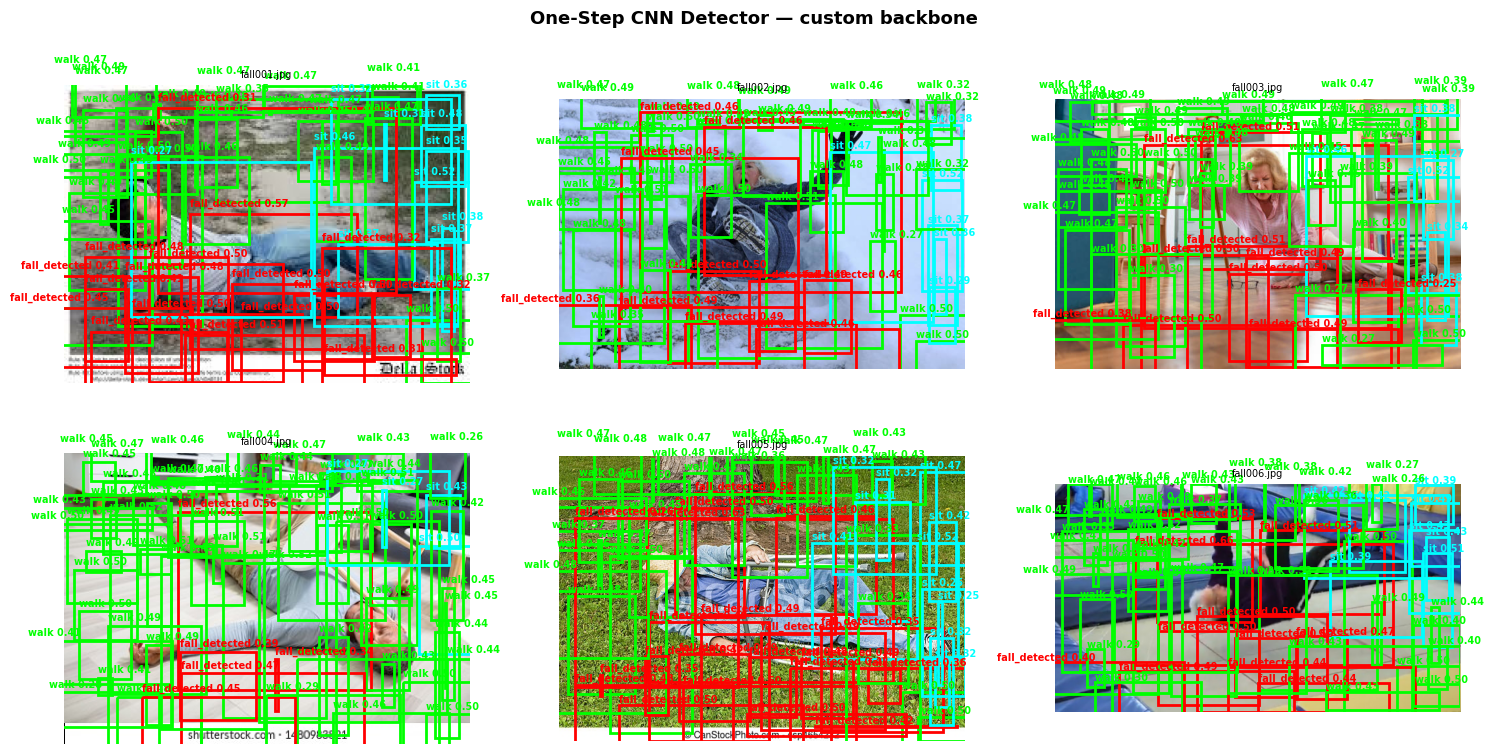

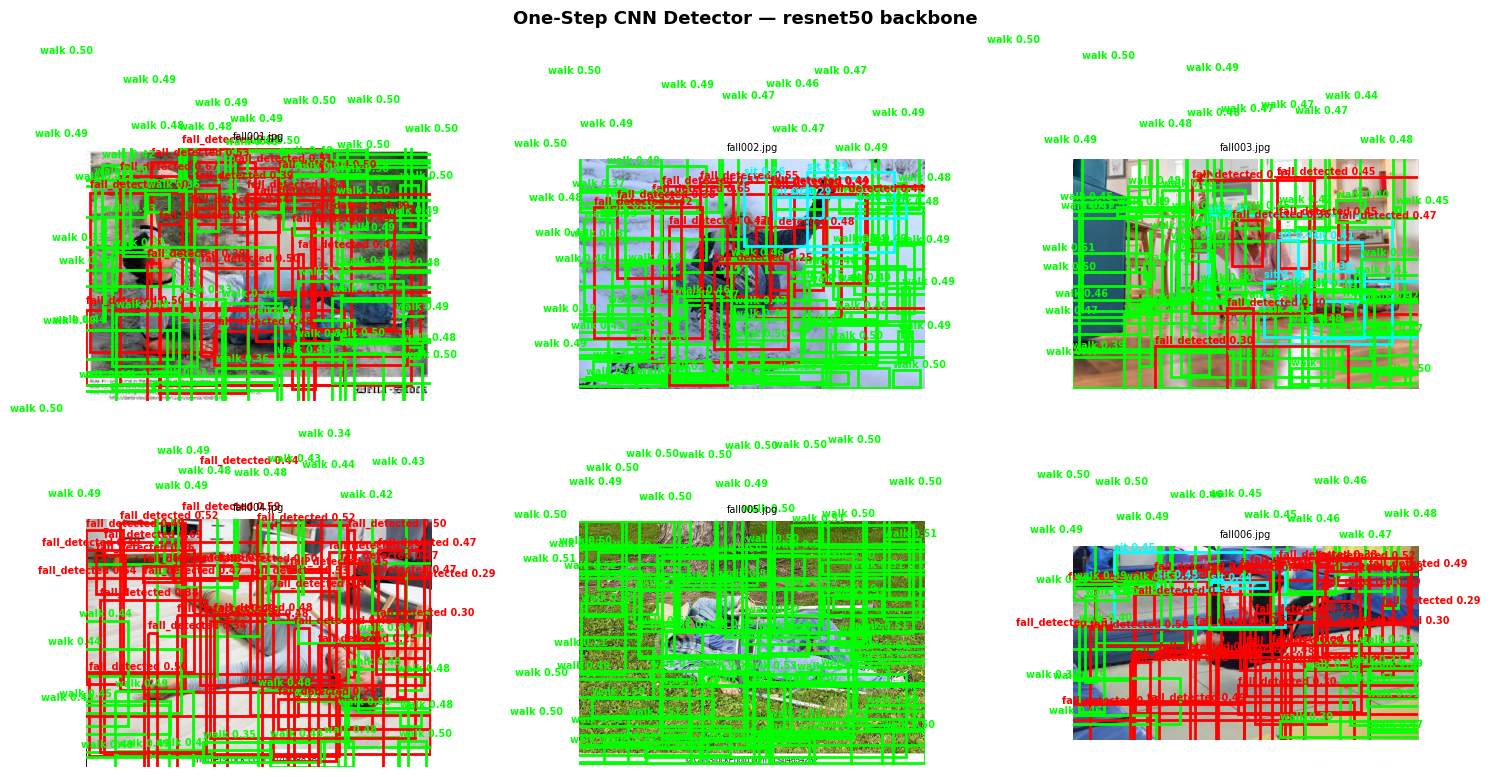

In [13]:
# ── Qualitative visualisation ─────────────────────────────────────────────────
test_imgs = list((IMG_DIR / 'val').glob('*.jpg'))[:6]
infer_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

BOX_COLORS = {'fall_detected': 'red', 'walk': 'lime', 'sit': 'cyan'}

for bname, model in trained_detectors.items():
    model.eval()
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for ax, img_path in zip(axes, test_imgs):
        img_pil = Image.open(img_path).convert('RGB')
        W, H    = img_pil.size

        tensor = infer_transform(img_pil).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            output = model(tensor)[0]   # [S, S, B*5+C]

        detections = decode_predictions(output, S=S, B=B, C=NUM_CLASSES,
                                         conf_thresh=0.25)

        ax.imshow(img_pil)
        for det in detections:
            x1, y1, x2, y2 = det['box']
            cls_name = CLASS_NAMES[det['class']]
            color    = BOX_COLORS.get(cls_name, 'white')
            rect = patches.Rectangle(
                (x1*W, y1*H), (x2-x1)*W, (y2-y1)*H,
                linewidth=2, edgecolor=color, facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(x1*W, y1*H - 5,
                    f"{cls_name} {det['score']:.2f}",
                    color=color, fontsize=7, fontweight='bold')
        ax.set_title(img_path.name, fontsize=7)
        ax.axis('off')

    plt.suptitle(f'One-Step CNN Detector — {bname} backbone',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'one_step_cnn_{bname}_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7. Evaluation — mAP Calculation

In [14]:
def compute_map(model, val_dataset, iou_threshold=0.5,
                conf_thresh=0.25, model_name=''):
    """
    Compute mean Average Precision (mAP@IoU) across all classes.
    """
    model.eval()
    all_preds   = defaultdict(list)   # cls_id -> list of (score, tp)
    all_gt_count = defaultdict(int)   # cls_id -> total GT instances

    infer_tf = T.Compose([
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.ToTensor(),
        T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])

    for i in range(len(val_dataset)):
        img_path  = val_dataset.img_files[i]
        img_pil   = Image.open(img_path).convert('RGB')
        tensor    = infer_tf(img_pil).unsqueeze(0).to(DEVICE)

        # Ground-truth boxes
        gt_boxes = []
        txt_path = val_dataset.label_dir / (img_path.stem + '.txt')
        if txt_path.exists():
            with open(txt_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        cls = int(parts[0])
                        cx, cy, bw, bh = map(float, parts[1:5])
                        x1, y1 = cx-bw/2, cy-bh/2
                        x2, y2 = cx+bw/2, cy+bh/2
                        gt_boxes.append({'class': cls, 'box': [x1,y1,x2,y2]})
                        all_gt_count[cls] += 1

        with torch.no_grad():
            output = model(tensor)[0]
        preds = decode_predictions(output, S=S, B=B, C=NUM_CLASSES,
                                    conf_thresh=conf_thresh)

        matched_gt = set()
        for pred in sorted(preds, key=lambda x: -x['score']):
            best_iou, best_idx = 0, -1
            for j, gt in enumerate(gt_boxes):
                if gt['class'] != pred['class'] or j in matched_gt:
                    continue
                iou = compute_iou(pred['box'], gt['box'])
                if iou > best_iou:
                    best_iou, best_idx = iou, j
            tp = 1 if (best_iou >= iou_threshold and best_idx >= 0) else 0
            if tp:
                matched_gt.add(best_idx)
            all_preds[pred['class']].append((pred['score'], tp))

    # ── Average Precision per class ──────────────────────────────────────────
    ap_per_class = {}
    for cls_id in range(NUM_CLASSES):
        preds_cls = sorted(all_preds[cls_id], key=lambda x: -x[0])
        n_gt = all_gt_count[cls_id]
        if n_gt == 0 or not preds_cls:
            ap_per_class[cls_id] = 0.0
            continue
        tp_cum = np.cumsum([p[1] for p in preds_cls])
        fp_cum = np.cumsum([1-p[1] for p in preds_cls])
        prec   = tp_cum / (tp_cum + fp_cum + 1e-6)
        rec    = tp_cum / n_gt
        # 11-point interpolation
        ap = 0
        for t in np.linspace(0, 1, 11):
            p_at_r = prec[rec >= t].max() if (rec >= t).any() else 0
            ap += p_at_r / 11
        ap_per_class[cls_id] = ap

    mAP = np.mean(list(ap_per_class.values()))

    print(f'\n=== {model_name} mAP@{iou_threshold} ===')
    for cls_id, name in enumerate(CLASS_NAMES):
        print(f'  {name:15s}: AP = {ap_per_class[cls_id]:.4f}')
    print(f'  {"mAP":15s}: {mAP:.4f}')
    return mAP, ap_per_class


map_results = {}
for bname, model in trained_detectors.items():
    mAP, ap_cls = compute_map(model, val_dataset, model_name=bname)
    map_results[bname] = {'mAP': mAP, 'per_class': ap_cls}


=== custom mAP@0.5 ===
  fall_detected  : AP = 0.2122
  walk           : AP = 0.0065
  sit            : AP = 0.0025
  mAP            : 0.0737

=== resnet50 mAP@0.5 ===
  fall_detected  : AP = 0.5401
  walk           : AP = 0.0117
  sit            : AP = 0.0332
  mAP            : 0.1950


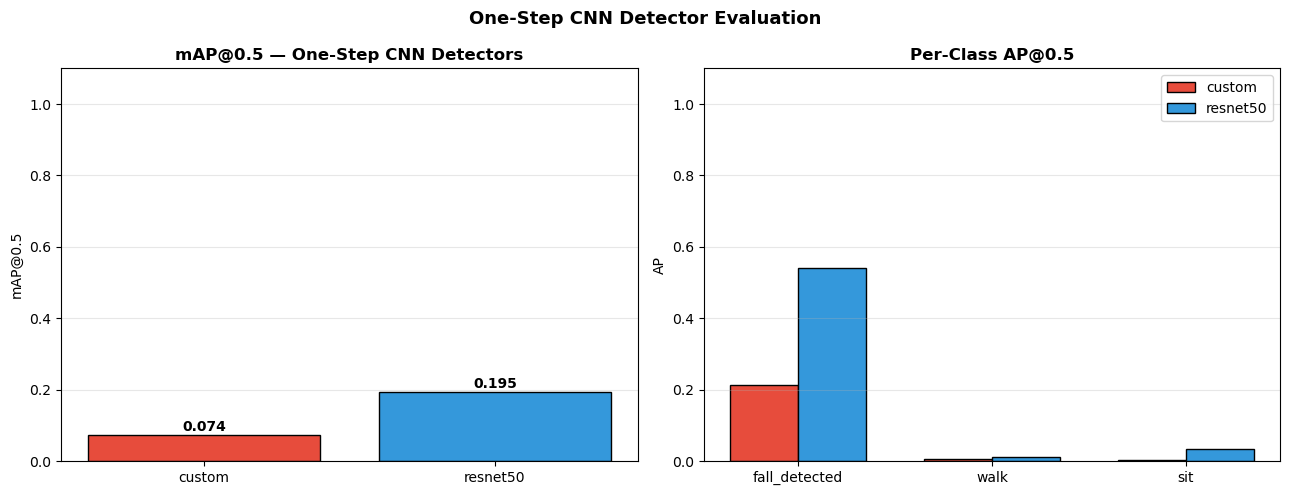

In [15]:
# ── mAP comparison bar chart ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# mAP summary
models_list = list(map_results.keys())
mAPs        = [map_results[b]['mAP'] for b in models_list]
axes[0].bar(models_list, mAPs, color=['#e74c3c', '#3498db'], edgecolor='black')
for i, (name, val) in enumerate(zip(models_list, mAPs)):
    axes[0].text(i, val + 0.01, f'{val:.3f}', ha='center', fontweight='bold')
axes[0].set_ylim(0, 1.1)
axes[0].set_title('mAP@0.5 — One-Step CNN Detectors', fontweight='bold')
axes[0].set_ylabel('mAP@0.5')
axes[0].grid(axis='y', alpha=0.3)

# Per-class AP
x   = np.arange(NUM_CLASSES)
w   = 0.35
for i, (bname, color) in enumerate(zip(models_list, ['#e74c3c', '#3498db'])):
    aps = [map_results[bname]['per_class'][c] for c in range(NUM_CLASSES)]
    axes[1].bar(x + i*w, aps, w, label=bname, color=color, edgecolor='black')

axes[1].set_xticks(x + w/2)
axes[1].set_xticklabels(CLASS_NAMES)
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Per-Class AP@0.5', fontweight='bold')
axes[1].set_ylabel('AP')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('One-Step CNN Detector Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('one_step_cnn_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary

### Architecture Breakdown

```
Input Image [3, 448, 448]
      │
      ▼
 CNN Backbone
 ┌─────────────────────────────────────────┐
 │  Option A: Custom CNN (7 conv stages)   │  trained from scratch
 │  Option B: ResNet-50 (ImageNet pretrained, frozen early layers) │
 └─────────────────────────────────────────┘
      │  Feature map [C_feat, S, S]
      ▼
 Detection Head (conv layers)
      │  [S, S, B*5 + C]  =  [7, 7, 13]
      ▼
 For each of 49 grid cells:
   • Box 1: cx, cy, w, h, objectness
   • Box 2: cx, cy, w, h, objectness
   • Class: P(fall) P(walk) P(sit)
      │
      ▼
 Post-processing:
   1. Sigmoid → constrain cx,cy,obj to [0,1]
   2. Cell offsets → image coordinates
   3. Threshold on confidence score
   4. Non-Maximum Suppression (NMS)
      │
      ▼
 Final detections: [(class, bbox, score), ...]
```

### Loss Components
| Loss Term | Weight | Purpose |
|---|---|---|
| `coord_loss` | ×5 | Penalise cx,cy,√w,√h errors |
| `obj_loss` | ×1 | Penalise confidence in object cells |
| `noobj_loss` | ×0.5 | Penalise false positives in empty cells |
| `class_loss` | ×1 | Cross-entropy on class predictions |

### Key Design Choices
- **√(w,h)** in loss prevents large boxes from dominating gradients
- **IoU-based responsible box selection** — only the better-predicting box updates on each GT
- **Two-phase training** — frozen backbone head-first, then full fine-tuning
- **Label smoothing + AdamW** — regularisation for the small dataset